In [104]:
import numpy as np
from matplotlib import pyplot as plt

In [105]:

def sigmoid(z):
    
    return 1 / (1 + np.exp(-z))
    

def forward_pass(x,w,b):
    
    z = w @ x + b
    a = sigmoid(z)
    
    return z,a

def softmax(z):
    
    return np.exp(z) / np.sum(np.exp(z))

In [111]:
#problem 1

x1 = 3
x2 = 5
x3 = 7

w1 = np.random.randn()
w2 = np.random.randn()
w3 = np.random.randn()

b = np.random.randn()


x = np.array([[x1,x2,x3]])
w = np.array([[w1,w2,w3]])

x_trans = x.T

out = forward_pass(x_trans,w,b)[1]
out

array([[0.47234161]])

In [19]:
#problem 2

x1 = 3
x2 = 5
x3 = 7

w = np.random.randn(3,3)
b = np.random.randn(3,1)

x = np.array([[x1,x2,x3]])

x_trans = x.T

out = forward_pass(x_trans,w,b)[0]
out = softmax(out)
out


array([[1.38768967e-01],
       [8.61231033e-01],
       [3.63140575e-14]])

In [112]:
#Problem 3

def loss_function(desired_output,output):
    
    loss = np.sum((desired_output - output)**2)
    
    return loss

desired_output = np.array([
    [0],
    [1],
    [0]])

loss = loss_function(desired_output,out)
loss

0.7246365729413368

In [77]:
#Problem 4

def forward_pass_new(weight,bias,input,desired_output):
    
    z = weight @ input + bias
    a = (np.exp(z) / np.sum(np.exp(z)))
    
    loss = np.sum((a - desired_output)**2)
    
    return z,a,loss

In [98]:


x = np.array([
    [3],
    [5],
    [7]
])

b = np.array([
  [1],
  [1],
  [1] 
])

desired_output = np.array([
    [0],
    [1],
    [0]
])




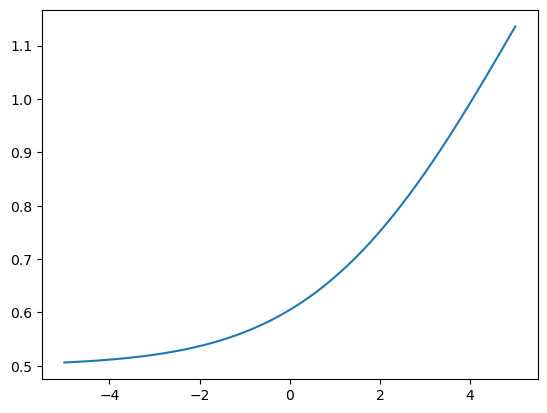

In [99]:


x_axsis = np.linspace(-5,5,1000)
y_axsis = np.zeros(len(x_axsis))

x_norm = x / np.linalg.norm(x)


for i, w_11 in enumerate(x_axsis):
    
    
    w = np.array([
    [w_11,1,1],
    [1,1,1],
    [1,1,1]
    ])
    

    z,a,loss = forward_pass_new(w,b,x_norm,desired_output)
    
    y_axsis[i] = loss

plt.plot(x_axsis,y_axsis)

In [102]:
#Problem 5 

x1 = 3
x2 = 5
x3 = 7


w = np.random.randn(3,3)
b = np.random.randn(3,1)

x = np.array([[x1,x2,x3]])
x_norm = x / np.linalg.norm(x)
x_trans = x_norm.T


def forward_pass_new(weight,bias,input,desired_output):
    
    z = weight @ input + bias
    a = (np.exp(z) / np.sum(np.exp(z)))
    
    loss = np.sum((a - desired_output)**2)
    
    return z,a,loss

desired_output = np.array([
    [0],
    [1],
    [0]])


# Gradient Vector

def gradient_vector(w,b,x_trans,desired_output):

    prev_loss = forward_pass_new(w,b,x_trans,desired_output)[2]

    h = 1e-7
    n_w = w.copy()
    n_b = b.copy()


    g_w = np.zeros_like(w)
    g_b = np.zeros_like(b)

    w_rows = w.shape[0]
    w_columns = w.shape[1]

    b_row = b.shape[0]
    b_columns = b.shape[1]


    for i in range(w_rows):
        for j in range(w_columns):
                
            n_w[i,j] = w[i,j] + h
            new_loss = forward_pass_new(n_w,n_b,x_trans,desired_output)[2]
            g_w[i,j] = (new_loss - prev_loss) / h
            n_w = w.copy()

    for i in range(b_row):
        for j in range(b_columns):
                
            n_b[i,j] = b[i,j] + h
            new_loss = forward_pass_new(n_w,n_b,x_trans,desired_output)[2]
            g_b[i,j] = (new_loss - prev_loss) / h
            n_b = b.copy()

    return g_w, g_b,prev_loss

In [103]:
# Gradient Descent

n = 0.5

for i in range(200):
    
    g_w, g_b,prev_loss = gradient_vector(w,b,x_trans,desired_output)
    w = w - (n*g_w)
    b = b - (n*g_b)
    print(prev_loss)

1.4282646904391445
1.4031401251769968
1.3846032592761368
1.3643001704739717
1.3379977403101118
1.3015565101339797
1.2485434213715496
1.167618780195751
1.039009699953842
0.8354476352513188
0.5563269348813653
0.30082720542022645
0.1634415564740385
0.10286881238104179
0.07278567203079905
0.05554498337445066
0.04457213657042043
0.03704836093917
0.0316005861036746
0.027489891240818985
0.024286700854233498
0.021725604207411944
0.01963438924902276
0.017896739975295867
0.0164314217855776
0.015180073729465626
0.01409974072882767
0.013158137743958223
0.012330551356981679
0.011597756772018946
0.010944583474462564
0.010358906342661824
0.009830922457281151
0.009352623746592873
0.00891740652259355
0.008519778240797969
0.008155134527530652
0.00781958759902101
0.007509832811780989
0.007223043863604162
0.006956789710782571
0.006708968167322015
0.006477752397191493
0.006261547480413072
0.006058954937733363
0.005868743529009698
0.005689825105025473
0.005521234508399501
0.0053621127555718625
0.00521169289